# 03 · Modelo do aluno: prever se o aluno será alfabetizado

Este é o objetivo principal do desafio: um modelo supervisionado que prevê se um aluno do 2º ano será considerado alfabetizado (proficiência de 743 ou mais na escala Saeb) a partir de variáveis educacionais, territoriais e socioeconômicas.

O protocolo segue o que ficou decidido na EDA:

- **treino e validação em 2024**, com validação cruzada que separa municípios inteiros (`StratifiedGroupKFold`), para que o mesmo município nunca esteja dos dois lados;
- **teste em 2025**, aberto uma única vez no fim, como um cofre;
- **pesos amostrais** do Inep nas métricas, para que os números sejam comparáveis com o indicador oficial;
- **um pipeline só**, com imputação, transformação, encoding e modelo, ajustado sempre dentro do fold.

O teto do problema também ficou claro na EDA: 85% da variação do alvo está entre alunos da mesma escola, nível em que não há variáveis. O que se espera do modelo é ordenar bem o risco entre escolas e municípios, e a métrica principal é o AUC-ROC (independe do limiar). Para a política pública, a classe que interessa é a de **não alfabetizado**, então o recall dessa classe é a métrica de operação.

In [1]:
import os
from pathlib import Path

if Path.cwd().name == "notebooks":
    os.chdir("..")

import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone

from src.data.abt import carregar_abt_aluno
from src.preprocessing.features import grupos_aluno, preparar_xy, colunas
from src.preprocessing.pipeline import build_pipeline, nomes_das_features
from src.preprocessing.splits import amostra_estratificada, split_temporal
from src.modeling.modelos import criar_modelos
from src.modeling.train import buscar_hiperparametros, resumo_da_busca, salvar_modelo
from src.evaluation.metricas import avaliar_classificacao, matriz_confusao, varrer_limiares, limiar_por_recall_negativos, curva_roc, curva_pr
from src.evaluation.validacao import validar_por_grupos, resumir_folds, curva_de_aprendizado
from src.visualization.estilo import aplicar_estilo, salvar, fmt_pct, AZUL, LARANJA, CINZA, VERDE, VERMELHO
from src.visualization.rotulos import rotulo

aplicar_estilo()
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
SEED = 42
# modo rapido (TC_RAPIDO=1): amostras menores e menos iteracoes, para conferir o notebook em poucos minutos
RAPIDO = os.environ.get("TC_RAPIDO") == "1"

## 1. Base, split temporal e variáveis

In [2]:
alunos = carregar_abt_aluno()
treino, teste = split_temporal(alunos, 2024, 2025, coluna_ano="ano")
if RAPIDO:
    treino = amostra_estratificada(treino, 200_000, "alfabetizado", seed=SEED)
print(f"treino 2024: {len(treino):,} alunos em {treino['id_municipio'].nunique():,} municípios | teste 2025: {len(teste):,} alunos")
print(f"alfabetizados no treino: {100 * treino['alfabetizado'].mean():.1f}% (ponderado: {100 * np.average(treino['alfabetizado'], weights=treino['peso']):.1f}%)")

grupos = grupos_aluno()
pd.DataFrame({bloco: pd.Series([rotulo(c) for c in cols]) for bloco, cols in grupos.items()}).fillna("")

treino 2024: 1,851,852 alunos em 5,517 municípios | teste 2025: 1,966,095 alunos
alfabetizados no treino: 59.8% (ponderado: 59.2%)


,historico,log,numericas,categoricas
0,% alfabetizados no ano anterior,Alunos avaliados na escola,Presença na prova na escola (%),Rede de ensino
1,Participação na prova no ano anterior (%),População (Censo 2022),"Docentes com formação adequada, anos iniciais (%)",UF
2,Salto necessário para a meta (p.p.),Área (km²),"Docentes sem licenciatura, anos iniciais (%)",
3,,Densidade demográfica (hab/km2),"Docentes com formação adequada, educação infan...",
4,,PIB per capita (R$),"Alunos por turma, anos iniciais",
5,,Alunos com INSE calculado,Alunos por turma no 2o ano,
6,,,Alunos por turma na pré-escola,
7,,,"Distorção idade-série, anos iniciais (%)",
8,,,Distorção idade-série no 2o ano (%),
9,,,"Docentes com curso superior, anos iniciais (%)",


Quatro blocos entram no `ColumnTransformer`: o histórico do indicador do município (mediana + indicador de ausência), as variáveis de porte e renda (mediana + log1p), as demais numéricas (mediana) e as categóricas (one-hot). Todos escalonados, porque a regressão logística precisa; para as árvores o escalonamento é inócuo.

In [3]:
x_treino, y_treino = preparar_xy(treino, grupos, "alfabetizado")
w_treino = treino["peso"].values
g_treino = treino["id_municipio"].values

exemplo = build_pipeline(grupos, criar_modelos()["logistica"][0])
exemplo

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('historico', ...), ('log', ...), ...]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_

## 2. Busca de hiperparâmetros em uma amostra

Com 1,85 milhão de linhas, a busca de hiperparâmetros na base inteira seria cara demais para o ganho. A busca é feita em uma **amostra estratificada de 300 mil alunos** (a proporção do alvo é preservada), com 3 folds por município. O modelo final é depois ajustado na base inteira com os melhores hiperparâmetros.

Três famílias, como nas aulas: regressão logística (baseline linear e interpretável), Random Forest (bagging) e LightGBM (gradient boosting). A busca é aleatória (`RandomizedSearchCV`), que cobre melhor o espaço do que a grade pelo mesmo custo. O critério é o AUC-ROC na validação.

In [4]:
amostra = amostra_estratificada(treino, 30_000 if RAPIDO else 300_000, "alfabetizado", seed=SEED)
x_am, y_am = preparar_xy(amostra, grupos, "alfabetizado")
w_am = amostra["peso"].values
g_am = amostra["id_municipio"].values
print(f"amostra: {len(amostra):,} alunos, {amostra['id_municipio'].nunique():,} municípios, {100 * y_am.mean():.1f}% alfabetizados")

resultados = {}
buscas = {}
n_iter = {"logistica": 2, "random_forest": 1, "lightgbm": 3} if RAPIDO else {"logistica": 6, "random_forest": 3, "lightgbm": 12}
for nome, (estimador, distribuicoes) in criar_modelos(n_jobs=-1).items():
    t0 = time.time()
    busca = buscar_hiperparametros(
        build_pipeline(grupos, estimador), distribuicoes, x_am, y_am, g_am,
        n_iter=n_iter[nome], n_splits=3, sample_weight=w_am, n_jobs=1,
    )
    buscas[nome] = busca
    tabela = resumo_da_busca(busca)
    resultados[nome] = {
        "auc_validacao": busca.best_score_,
        "auc_treino": tabela.loc[0, "mean_train_score"],
        "desvio_validacao": tabela.loc[0, "std_test_score"],
        "tempo_min": (time.time() - t0) / 60,
        "melhores": busca.best_params_,
    }
    print(f"{nome:14s} AUC validação {busca.best_score_:.4f} (treino {tabela.loc[0, 'mean_train_score']:.4f}) em {resultados[nome]['tempo_min']:.1f} min")

amostra: 300,000 alunos, 5,499 municípios, 59.8% alfabetizados


logistica      AUC validação 0.6643 (treino 0.6682) em 3.7 min


random_forest  AUC validação 0.6646 (treino 0.6918) em 37.2 min


lightgbm       AUC validação 0.6666 (treino 0.6920) em 9.4 min


In [5]:
comparacao = pd.DataFrame(resultados).T
comparacao["gap_treino_validacao"] = comparacao["auc_treino"] - comparacao["auc_validacao"]
comparacao[["auc_validacao", "desvio_validacao", "auc_treino", "gap_treino_validacao", "tempo_min"]].astype(float).round(4)

,auc_validacao,desvio_validacao,auc_treino,gap_treino_validacao,tempo_min
logistica,0.6643,0.0045,0.6682,0.0039,3.7054
random_forest,0.6646,0.0052,0.6918,0.0272,37.2458
lightgbm,0.6666,0.0044,0.6920,0.0255,9.4261


In [6]:
melhor_nome = comparacao["auc_validacao"].astype(float).idxmax()
melhores_params = {k.replace("modelo__", ""): v for k, v in resultados[melhor_nome]["melhores"].items()}
print("melhor família:", melhor_nome)
pd.Series(melhores_params, name="hiperparâmetro").to_frame()

melhor família: lightgbm


,hiperparâmetro
colsample_bytree,0.904199
max_depth,11.000000
min_child_samples,72.000000
num_leaves,16.000000
reg_lambda,1.129013
subsample,0.776061
subsample_freq,1.000000


In [7]:
resumo_da_busca(buscas["lightgbm"]).head(8).round(4)

,colsample_bytree,max_depth,min_child_samples,num_leaves,reg_lambda,subsample,subsample_freq,mean_train_score,mean_test_score,std_test_score
0,0.9042,11,72,16,1.1290,0.7761,1,0.6920,0.6666,0.0044
1,0.8876,4,221,76,6.0253,0.8909,1,0.6861,0.6666,0.0044
2,0.9869,5,74,78,0.2514,0.9440,1,0.6957,0.6661,0.0050
3,0.8777,8,73,18,0.0359,0.9878,1,0.6931,0.6659,0.0049
4,0.5290,10,119,38,0.8967,0.6226,1,0.7058,0.6658,0.0044
5,0.6357,7,299,40,7.8662,0.8428,1,0.7027,0.6655,0.0044
6,0.6873,10,208,35,0.0294,0.6624,1,0.7050,0.6654,0.0049
7,0.8402,11,186,32,7.0252,0.9863,1,0.7031,0.6653,0.0045


O boosting fica à frente, mas a distância para a regressão logística é pequena: o sinal disponível é majoritariamente linear no contexto, e a parte que as árvores capturam a mais são interações (UF com histórico, presença com porte da escola). O gap entre treino e validação é pequeno em todas as famílias, o que indica pouco overfitting; dado o teto do problema, isso é o esperado.

## 3. Ablação: o que cada bloco de variáveis acrescenta

Uma pergunta que a EDA deixou aberta: quanto o modelo é só um repetidor do histórico do município? A ablação treina o melhor modelo com subconjuntos de variáveis, na mesma validação por grupos.

In [8]:
def subgrupos(**kw):
    return {k: [c for c in v if c not in kw.get("remover", [])] for k, v in grupos.items() if k in kw.get("manter", grupos)}

variantes = {
    "só aluno e escola (rede, UF, tamanho, presença)": {
        "historico": [], "log": ["escola_qtd_avaliados"], "numericas": ["escola_taxa_presenca"], "categoricas": ["rede", "sigla_uf"],
    },
    "contexto municipal sem histórico": {
        "historico": [], "log": grupos["log"], "numericas": grupos["numericas"], "categoricas": grupos["categoricas"],
    },
    "só histórico do indicador e UF": {
        "historico": grupos["historico"], "log": [], "numericas": [], "categoricas": ["sigla_uf"],
    },
    "completo": grupos,
}
estimador_base = clone(criar_modelos(n_jobs=-1)[melhor_nome][0]).set_params(**melhores_params)
ablacao = []
for nome, gr in variantes.items():
    xa, ya = preparar_xy(amostra, gr, "alfabetizado")
    tabela, _ = validar_por_grupos(build_pipeline(gr, estimador_base), xa, ya, g_am, n_splits=3, sample_weight=w_am)
    r = resumir_folds(tabela)
    ablacao.append({"variáveis": nome, "n_variáveis": len(colunas(gr)), "auc_validacao": r.loc["validacao", ("media", "auc_roc")], "auc_treino": r.loc["treino", ("media", "auc_roc")]})
ablacao = pd.DataFrame(ablacao)
ablacao.round(4)

,variáveis,n_variáveis,auc_validacao,auc_treino
0,"só aluno e escola (rede, UF, tamanho, presença)",4,0.6421,0.6639
1,contexto municipal sem histórico,39,0.6586,0.6892
2,só histórico do indicador e UF,4,0.6491,0.6684
3,completo,42,0.6644,0.6907


Leitura da ablação: os quatro atributos de aluno e escola (rede, UF, tamanho e presença) já dão a maior parte do AUC, o que confirma o peso da UF e da presença. O contexto municipal sem nenhum histórico chega mais perto do modelo completo do que o histórico sozinho; ou seja, o modelo não é um repetidor do resultado anterior, e em um município novo, sem resultado publicado, continua útil. A combinação de tudo é o melhor, por pouco: as variáveis se sobrepõem bastante, como a matriz de correlação da EDA já mostrava.

## 4. Curva de aprendizado

A curva de aprendizado diz se mais dados ajudariam (curvas ainda convergindo) ou se o modelo bateu no teto do que as variáveis permitem (curvas paralelas e próximas). Feita na amostra, com validação por grupos.

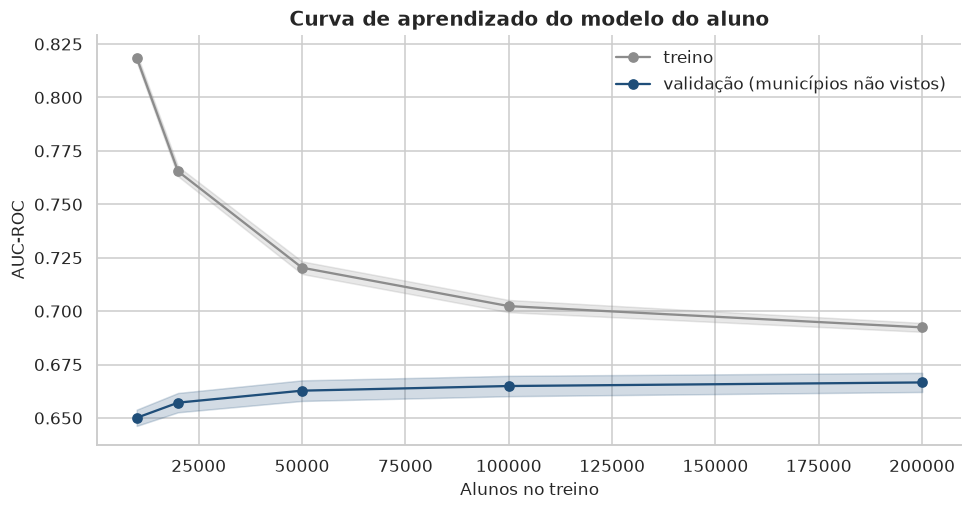

,tamanho,treino_media,treino_desvio,validacao_media,validacao_desvio
0,10000,0.8186,0.0020,0.6501,0.0038
1,20000,0.7654,0.0023,0.6572,0.0045
2,50002,0.7203,0.0029,0.6628,0.0048
3,100004,0.7023,0.0029,0.6649,0.0048
4,200008,0.6924,0.0021,0.6666,0.0045


In [9]:
curva = curva_de_aprendizado(build_pipeline(grupos, clone(estimador_base).set_params(n_jobs=-1)), x_am, y_am, g_am, fracoes=(0.05, 0.1, 0.25, 0.5, 1.0), n_splits=3, n_jobs=1)
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(curva["tamanho"], curva["treino_media"], marker="o", color=CINZA, label="treino")
ax.fill_between(curva["tamanho"], curva["treino_media"] - curva["treino_desvio"], curva["treino_media"] + curva["treino_desvio"], color=CINZA, alpha=0.2)
ax.plot(curva["tamanho"], curva["validacao_media"], marker="o", color=AZUL, label="validação (municípios não vistos)")
ax.fill_between(curva["tamanho"], curva["validacao_media"] - curva["validacao_desvio"], curva["validacao_media"] + curva["validacao_desvio"], color=AZUL, alpha=0.2)
ax.set_xlabel("Alunos no treino")
ax.set_ylabel("AUC-ROC")
ax.set_title("Curva de aprendizado do modelo do aluno")
ax.legend()
salvar(fig, "03_curva_aprendizado")
plt.show()
curva.round(4)

As duas curvas se aproximam e a de validação estabiliza bem antes do fim: o modelo não está limitado por quantidade de dados, e sim pelo que as variáveis conseguem explicar. Mais alunos não resolvem; variáveis do aluno e da escola resolveriam. Isso vai para as evoluções futuras.

## 5. Ajuste final em 2024 e escolha do ponto de operação

O modelo final é ajustado nos 1,85 milhão de alunos de 2024, com os pesos amostrais. Para escolher o limiar sem tocar em 2025, uso as probabilidades fora da amostra de uma validação por grupos na base inteira (3 folds).

O critério de operação vem da política pública: o objetivo é **encontrar as crianças em risco de não alfabetização**, então o limiar é escolhido para garantir um recall mínimo de 70% da classe "não alfabetizado", e a precisão que sobra é o custo desse recall.

In [10]:
modelo_final = build_pipeline(grupos, clone(estimador_base).set_params(n_jobs=-1))
t0 = time.time()
folds, oof = validar_por_grupos(modelo_final, x_treino, y_treino, g_treino, n_splits=3, sample_weight=w_treino)
print(f"validação por grupos na base inteira: {(time.time() - t0) / 60:.1f} min")
resumir_folds(folds)

validação por grupos na base inteira: 3.3 min


media                                   desvio                                 
          auc_roc  auc_pr      f1 recall_negativos auc_roc  auc_pr      f1 recall_negativos
conjunto                                                                                   
treino     0.6803  0.7534  0.7300           0.4017  0.0040  0.0024  0.0029           0.0060
validacao  0.6630  0.7378  0.7225           0.3912  0.0107  0.0081  0.0155           0.0403

In [11]:
limiares = varrer_limiares(y_treino.values, oof, sample_weight=w_treino, passo=0.05)
limiar_op = limiar_por_recall_negativos(y_treino.values, oof, recall_minimo=0.70, sample_weight=w_treino)
print(f"limiar de operação (recall de não alfabetizados >= 70%): {limiar_op:.2f}")
limiares[["limiar", "acuracia", "precisao", "recall", "f1", "precisao_negativos", "recall_negativos"]].round(3)

limiar de operação (recall de não alfabetizados >= 70%): 0.63


,limiar,acuracia,precisao,recall,f1,precisao_negativos,recall_negativos
0,0.10,0.592,0.592,1.000,0.744,0.000,0.000
1,0.15,0.592,0.592,1.000,0.744,1.000,0.000
2,0.20,0.592,0.592,1.000,0.744,0.692,0.000
3,0.25,0.592,0.592,1.000,0.744,0.758,0.000
4,0.30,0.595,0.594,0.996,0.745,0.723,0.013
5,0.35,0.606,0.603,0.979,0.747,0.685,0.065
6,0.40,0.620,0.617,0.945,0.746,0.650,0.149
7,0.45,0.630,0.634,0.888,0.740,0.612,0.257
8,0.50,0.635,0.657,0.803,0.723,0.578,0.391
9,0.55,0.628,0.682,0.696,0.689,0.546,0.530


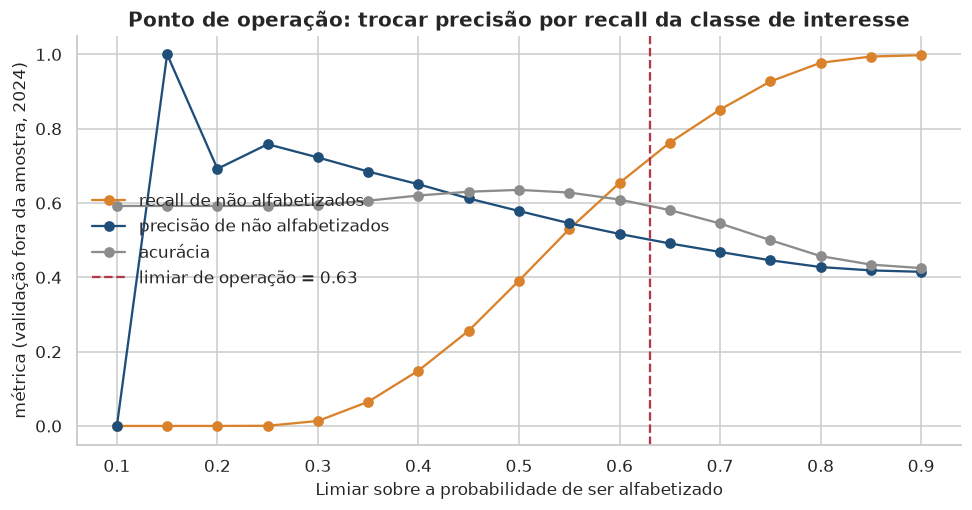

In [12]:
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(limiares["limiar"], limiares["recall_negativos"], marker="o", color=LARANJA, label="recall de não alfabetizados")
ax.plot(limiares["limiar"], limiares["precisao_negativos"], marker="o", color=AZUL, label="precisão de não alfabetizados")
ax.plot(limiares["limiar"], limiares["acuracia"], marker="o", color=CINZA, label="acurácia")
ax.axvline(limiar_op, color=VERMELHO, ls="--", label=f"limiar de operação = {limiar_op:.2f}")
ax.set_xlabel("Limiar sobre a probabilidade de ser alfabetizado")
ax.set_ylabel("métrica (validação fora da amostra, 2024)")
ax.set_title("Ponto de operação: trocar precisão por recall da classe de interesse")
ax.legend(loc="center left")
salvar(fig, "03_limiar_operacao")
plt.show()

In [13]:
t0 = time.time()
modelo_final.fit(x_treino, y_treino, modelo__sample_weight=w_treino)
print(f"ajuste final em {len(x_treino):,} alunos: {(time.time() - t0) / 60:.1f} min")

ajuste final em 1,851,852 alunos: 1.2 min


## 6. Teste em 2025: o cofre é aberto uma vez

Tudo até aqui usou só 2024. Agora o modelo é aplicado aos alunos de 2025, com o limiar já escolhido. Como a EDA mostrou, 2025 teve um salto nacional de alfabetização, então a taxa base mudou (66% contra 60%); é exatamente o tipo de deriva que um teste temporal precisa expor.

In [14]:
x_teste, y_teste = preparar_xy(teste, grupos, "alfabetizado")
w_teste = teste["peso"].values
proba_teste = modelo_final.predict_proba(x_teste)[:, 1]

metricas_teste = {
    "validação 2024 (fora da amostra, limiar 0,5)": avaliar_classificacao(y_treino.values, oof, 0.5, w_treino),
    "validação 2024 (fora da amostra, limiar de operação)": avaliar_classificacao(y_treino.values, oof, limiar_op, w_treino),
    "teste 2025 (limiar 0,5)": avaliar_classificacao(y_teste.values, proba_teste, 0.5, w_teste),
    "teste 2025 (limiar de operação)": avaliar_classificacao(y_teste.values, proba_teste, limiar_op, w_teste),
}
pd.DataFrame(metricas_teste).T.round(3)

,auc_roc,auc_pr,acuracia,precisao,recall,f1,precisao_negativos,recall_negativos,limiar,taxa_base
"validação 2024 (fora da amostra, limiar 0,5)",0.663,0.738,0.635,0.657,0.803,0.723,0.578,0.391,0.50,0.592
"validação 2024 (fora da amostra, limiar de operação)",0.663,0.738,0.594,0.724,0.508,0.597,0.502,0.718,0.63,0.592
"teste 2025 (limiar 0,5)",0.646,0.776,0.651,0.704,0.809,0.753,0.490,0.350,0.50,0.656
teste 2025 (limiar de operação),0.646,0.776,0.577,0.761,0.518,0.617,0.428,0.689,0.63,0.656


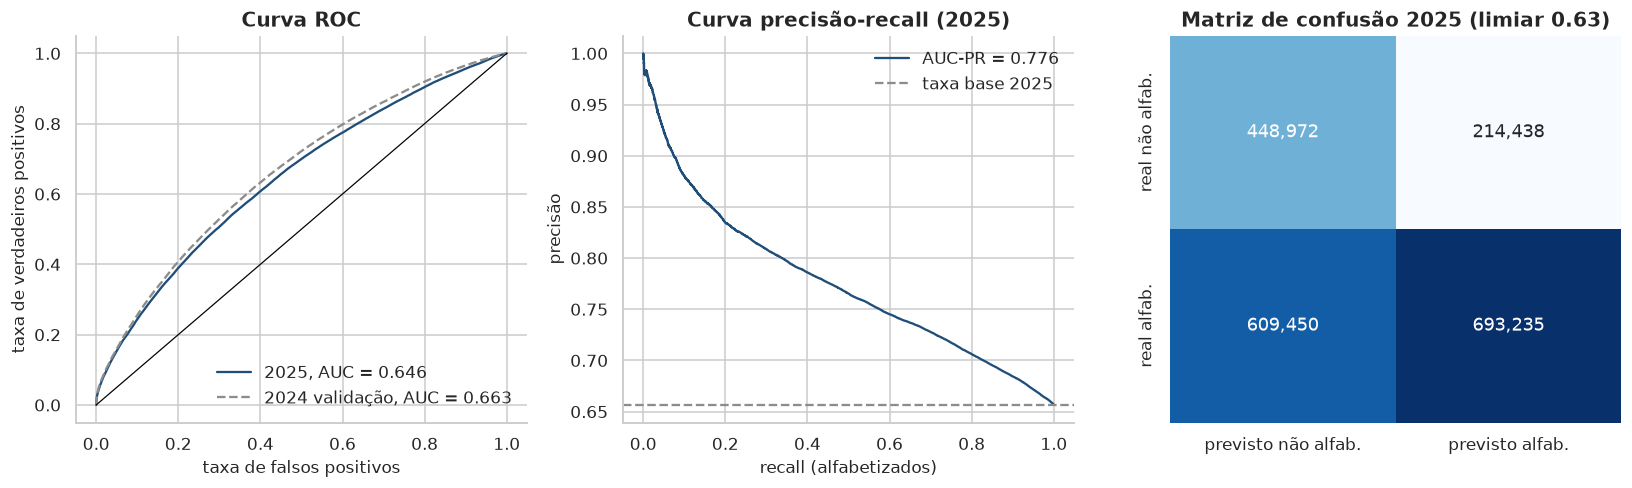

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
roc = curva_roc(y_teste.values, proba_teste, w_teste)
axes[0].plot(roc["fpr"], roc["tpr"], color=AZUL, label=f"2025, AUC = {metricas_teste['teste 2025 (limiar 0,5)']['auc_roc']:.3f}")
roc24 = curva_roc(y_treino.values, oof, w_treino)
axes[0].plot(roc24["fpr"], roc24["tpr"], color=CINZA, ls="--", label=f"2024 validação, AUC = {metricas_teste['validação 2024 (fora da amostra, limiar 0,5)']['auc_roc']:.3f}")
axes[0].plot([0, 1], [0, 1], color="black", lw=0.8)
axes[0].set_xlabel("taxa de falsos positivos")
axes[0].set_ylabel("taxa de verdadeiros positivos")
axes[0].set_title("Curva ROC")
axes[0].legend(loc="lower right")

pr = curva_pr(y_teste.values, proba_teste, w_teste)
axes[1].plot(pr["recall"], pr["precisao"], color=AZUL, label=f"AUC-PR = {metricas_teste['teste 2025 (limiar 0,5)']['auc_pr']:.3f}")
axes[1].axhline(metricas_teste["teste 2025 (limiar 0,5)"]["taxa_base"], color=CINZA, ls="--", label="taxa base 2025")
axes[1].set_xlabel("recall (alfabetizados)")
axes[1].set_ylabel("precisão")
axes[1].set_title("Curva precisão-recall (2025)")
axes[1].legend()

mc = matriz_confusao(y_teste.values, proba_teste, limiar_op, rotulos=("não alfab.", "alfab."))
sns.heatmap(mc, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=axes[2])
axes[2].set_title(f"Matriz de confusão 2025 (limiar {limiar_op:.2f})")
salvar(fig, "03_teste_2025")
plt.show()

O AUC de 2025 fica próximo do de validação em 2024: o ranking de risco que o modelo aprendeu se manteve válido no ano seguinte, apesar do salto nacional. O que muda com a deriva é a calibração: como 2025 teve mais alfabetizados do que 2024, a probabilidade prevista fica sistematicamente abaixo da realidade, e o limiar escolhido em 2024 classifica mais alunos como "não alfabetizados" do que deveria. É por isso que a operação deve reestimar o limiar a cada ano com o dado mais recente.

## 7. Análise de erros: onde o modelo acerta e onde falha

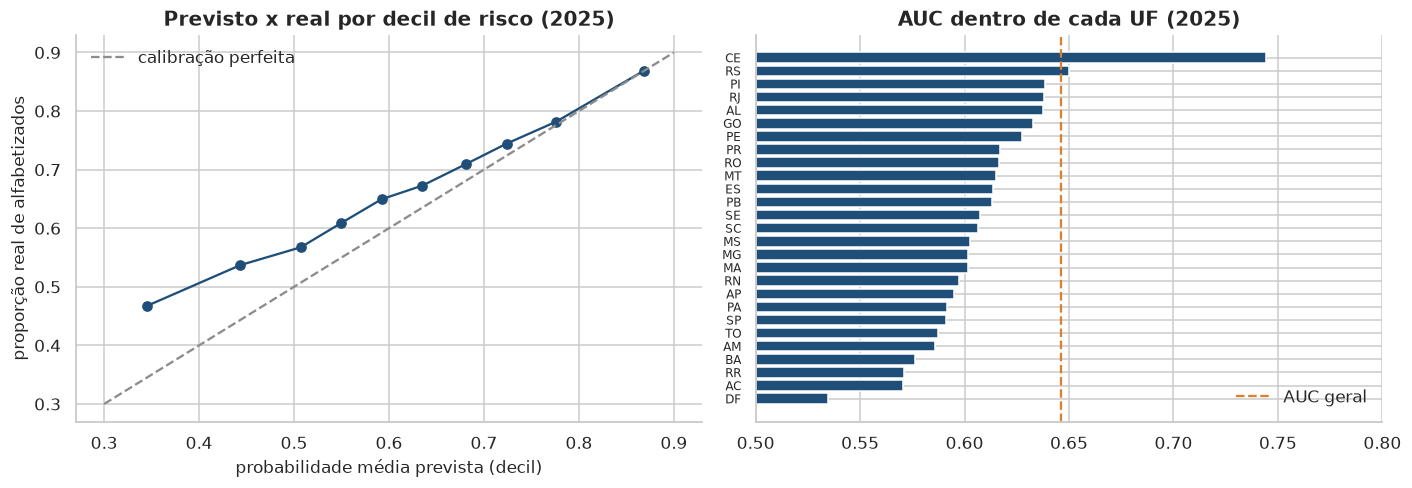

,prob_media_prevista,taxa_real,alunos
decil,,,
1,0.345,0.468,196678.0
2,0.444,0.537,196558.0
3,0.507,0.567,196611.0
4,0.550,0.609,196599.0
5,0.592,0.649,196668.0
6,0.635,0.673,196555.0
7,0.681,0.710,196600.0
8,0.724,0.745,196650.0
9,0.776,0.782,196575.0


In [16]:
avaliacao = teste[["sigla_uf", "rede", "id_municipio", "peso", "alfabetizado"]].copy()
avaliacao["proba"] = proba_teste
avaliacao["decil"] = pd.qcut(avaliacao["proba"], 10, labels=False, duplicates="drop") + 1

por_decil = avaliacao.groupby("decil").apply(
    lambda g: pd.Series({"prob_media_prevista": np.average(g["proba"], weights=g["peso"]), "taxa_real": np.average(g["alfabetizado"], weights=g["peso"]), "alunos": len(g)}),
    include_groups=False,
)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
axes[0].plot(por_decil["prob_media_prevista"], por_decil["taxa_real"], marker="o", color=AZUL)
axes[0].plot([0.3, 0.9], [0.3, 0.9], color=CINZA, ls="--", label="calibração perfeita")
axes[0].set_xlabel("probabilidade média prevista (decil)")
axes[0].set_ylabel("proporção real de alfabetizados")
axes[0].set_title("Previsto x real por decil de risco (2025)")
axes[0].legend()

from sklearn.metrics import roc_auc_score
por_uf = avaliacao.groupby("sigla_uf").apply(lambda g: pd.Series({"auc": roc_auc_score(g["alfabetizado"], g["proba"], sample_weight=g["peso"]) if g["alfabetizado"].nunique() > 1 else np.nan, "taxa_real": np.average(g["alfabetizado"], weights=g["peso"]), "prob_media": np.average(g["proba"], weights=g["peso"])}), include_groups=False).sort_values("auc")
axes[1].barh(por_uf.index, por_uf["auc"], color=AZUL)
axes[1].axvline(metricas_teste["teste 2025 (limiar 0,5)"]["auc_roc"], color=LARANJA, ls="--", label="AUC geral")
axes[1].set_xlim(0.5, max(0.8, por_uf["auc"].max() + 0.02))
axes[1].set_title("AUC dentro de cada UF (2025)")
axes[1].tick_params(axis="y", labelsize=8)
axes[1].legend()
salvar(fig, "03_erros_calibracao_uf")
plt.show()
por_decil.round(3)

In [17]:
por_uf["vies_pp"] = 100 * (por_uf["prob_media"] - por_uf["taxa_real"])
por_uf.round(3).sort_values("vies_pp")

,auc,taxa_real,prob_media,vies_pp
sigla_uf,,,,
BA,0.576,0.553,0.361,-19.188
RO,0.617,0.753,0.584,-16.876
PI,0.639,0.769,0.649,-12.007
PB,0.613,0.707,0.589,-11.815
PR,0.617,0.797,0.680,-11.716
AC,0.570,0.680,0.571,-10.914
AL,0.638,0.638,0.531,-10.630
AP,0.595,0.597,0.491,-10.606
PA,0.592,0.581,0.490,-9.082


Dois padrões. Primeiro, o ranking funciona: a proporção real de alfabetizados sobe decil a decil, do primeiro (maior risco) ao último. Segundo, o AUC **dentro** de cada UF é bem menor do que o geral: boa parte do poder do modelo vem de separar UFs, e dentro de uma mesma UF, com a mesma prova e o mesmo contexto estadual, sobra menos para separar. O viés por UF mostra onde a deriva de 2025 foi maior (os estados que mais subiram são os que o modelo mais subestima).

Para um gestor estadual, a leitura é direta: o modelo ordena escolas e municípios dentro do estado com poder moderado, e a lista de prioridade deve ser usada como triagem, não como veredito sobre cada aluno.

## 8. Persistência e registro

In [18]:
metadados = {
    "alvo": "alfabetizado (proficiência >= 743)",
    "universo": "alunos presentes com prova preenchida; ausentes fora",
    "treino": "2024 completo com pesos amostrais",
    "validacao": "StratifiedGroupKFold por município, 3 folds; busca em amostra estratificada de 300 mil",
    "teste": "2025, aberto uma vez",
    "modelo": melhor_nome,
    "hiperparametros": melhores_params,
    "limiar_operacao": limiar_op,
    "criterio_limiar": "recall de não alfabetizados >= 70% na validação de 2024",
    "comparacao_familias": {k: {"auc_validacao": float(v["auc_validacao"]), "auc_treino": float(v["auc_treino"])} for k, v in resultados.items()},
    "ablacao": ablacao.to_dict(orient="records"),
    "metricas": {k: {m: float(x) for m, x in v.items()} for k, v in metricas_teste.items()},
    "features": grupos,
}
caminho = salvar_modelo(modelo_final, "modelo_aluno", metadados)
Path("models/modelo_aluno_oof_2024.parquet").parent.mkdir(exist_ok=True)
pd.DataFrame({"id_aluno": treino["id_aluno"].values, "proba_oof": oof}).to_parquet("models/modelo_aluno_oof_2024.parquet", index=False)
avaliacao[["id_municipio", "sigla_uf", "rede", "proba", "alfabetizado", "peso"]].to_parquet("models/modelo_aluno_pred_2025.parquet", index=False)
print("salvo em", caminho)

salvo em models/modelo_aluno.joblib


## 9. O que fica registrado

- **Pipeline único** (imputação, log, escalonamento, one-hot e modelo) ajustado dentro do fold; nada é ajustado antes do split.
- **Sem leakage temporal**: só variáveis conhecidas antes da prova; teste em 2025 aberto uma vez.
- **Generalização**: validação por grupos de município em 2024 e teste temporal em 2025 dão AUC próximos; o gap treino-validação é pequeno; a curva de aprendizado mostra que o limite é de variáveis, não de dados.
- **Ponto de operação** definido pela política (recall de não alfabetizados), não pelo padrão de 0,5.
- **Limitação principal**: o modelo só enxerga o contexto; 85% da variação é individual. Ele serve para triagem de escolas e municípios, não para rotular um aluno.

O notebook 06 abre o modelo com SHAP para responder quais variáveis mais pesam.